In [5]:
PDF_PATH   = "lec.pdf"    # путь к PDF
PAGE_NUMS  = [1, 2, 3]    # None → все страницы
OCR_MODE   = "format"     # 'ocr' | 'format'
DPI        = 200          # 200 — быстро, 300 — точнее
RESULTS_DIR = "got_ocr_results"

In [6]:
import json
import time
from pathlib import Path

import torch
from pdf2image import convert_from_path
from PIL import Image
from IPython.display import display, Markdown, Image as IPImage
from transformers import AutoModelForCausalLM, AutoTokenizer

Path(RESULTS_DIR).mkdir(exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device : {device}")
if device == "cuda":
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device : cuda
GPU    : NVIDIA GeForce RTX 2080 Ti
VRAM   : 11.3 GB


In [12]:
import os
from pdf2image import convert_from_path
from PIL import Image, ImageOps

# -- Настройки -------------------------------------------------
PDF_PATH  = "/home/user/project/lol_xd.pdf"
PAGE_NUMS = None        # None = все страницы
DPI       = 300         # 300 оптимально для разметки рукописи

TARGET_WIDTH  = 1240    # A4 при 150 DPI — стандарт для Label Studio
TARGET_HEIGHT = 1754
OUTPUT_DIR    = "images_for_labeling"

# -- Конвертация -----------------------------------------------
print(f"Конвертация {PDF_PATH} (DPI={DPI})...")
all_images = convert_from_path(PDF_PATH, dpi=DPI)
total = len(all_images)
print(f"Всего страниц: {total}")

indices = ([p - 1 for p in PAGE_NUMS if 1 <= p <= total]
           if PAGE_NUMS else list(range(total)))

os.makedirs(OUTPUT_DIR, exist_ok=True)

# -- Обработка и сохранение ------------------------------------
for i in indices:
    img = all_images[i].convert("RGB")

    # 1. Приводим к единому размеру с сохранением пропорций
    img.thumbnail((TARGET_WIDTH, TARGET_HEIGHT), Image.LANCZOS)

    # 2. Добиваем до точного размера белым фоном (padding)
    canvas = Image.new("RGB", (TARGET_WIDTH, TARGET_HEIGHT), (255, 255, 255))
    offset = ((TARGET_WIDTH  - img.width)  // 2,
              (TARGET_HEIGHT - img.height) // 2)
    canvas.paste(img, offset)

    # 3. Лёгкое повышение контраста — улучшает читаемость рукописи
    canvas = ImageOps.autocontrast(canvas, cutoff=1)

    filename = f"page_{i+1:03d}.png"
    canvas.save(os.path.join(OUTPUT_DIR, filename), "PNG", optimize=True)
    print(f"  Сохранено: {filename} ({canvas.width}x{canvas.height})")

print(f"\nГотово! {len(indices)} изображений в '{OUTPUT_DIR}'")
print(f"Формат: {TARGET_WIDTH}x{TARGET_HEIGHT} px, RGB PNG")

Конвертация /home/user/project/lol_xd.pdf (DPI=300)...
Всего страниц: 39
  Сохранено: page_001.png (1240x1754)
  Сохранено: page_002.png (1240x1754)
  Сохранено: page_003.png (1240x1754)
  Сохранено: page_004.png (1240x1754)
  Сохранено: page_005.png (1240x1754)
  Сохранено: page_006.png (1240x1754)
  Сохранено: page_007.png (1240x1754)
  Сохранено: page_008.png (1240x1754)
  Сохранено: page_009.png (1240x1754)
  Сохранено: page_010.png (1240x1754)
  Сохранено: page_011.png (1240x1754)
  Сохранено: page_012.png (1240x1754)
  Сохранено: page_013.png (1240x1754)
  Сохранено: page_014.png (1240x1754)
  Сохранено: page_015.png (1240x1754)
  Сохранено: page_016.png (1240x1754)
  Сохранено: page_017.png (1240x1754)
  Сохранено: page_018.png (1240x1754)
  Сохранено: page_019.png (1240x1754)
  Сохранено: page_020.png (1240x1754)
  Сохранено: page_021.png (1240x1754)
  Сохранено: page_022.png (1240x1754)
  Сохранено: page_023.png (1240x1754)
  Сохранено: page_024.png (1240x1754)
  Сохранено: pa

In [8]:
from PIL import Image
from surya.foundation import FoundationPredictor
from surya.recognition import RecognitionPredictor
from surya.detection import DetectionPredictor
from surya.layout import LayoutPredictor
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

# -- Настройки -------------------------------------------------
PAGES_TO_CHECK = [1, 2, 3]
LANGS = ["ru"]  # язык для OCR

In [9]:


# -- Загрузка моделей ------------------------------------------
print("Загрузка моделей...")
foundation_predictor  = FoundationPredictor()
recognition_predictor = RecognitionPredictor(foundation_predictor)
detection_predictor   = DetectionPredictor()
layout_predictor      = LayoutPredictor(FoundationPredictor())
print("Готово.\n")

Загрузка моделей...
Готово.



OCR...


Recognizing Text: 100%|██████████| 109/109 [00:17<00:00,  6.32it/s]


Layout...


Recognizing Layout: 100%|██████████| 3/3 [00:01<00:00,  2.94it/s]


Готово.



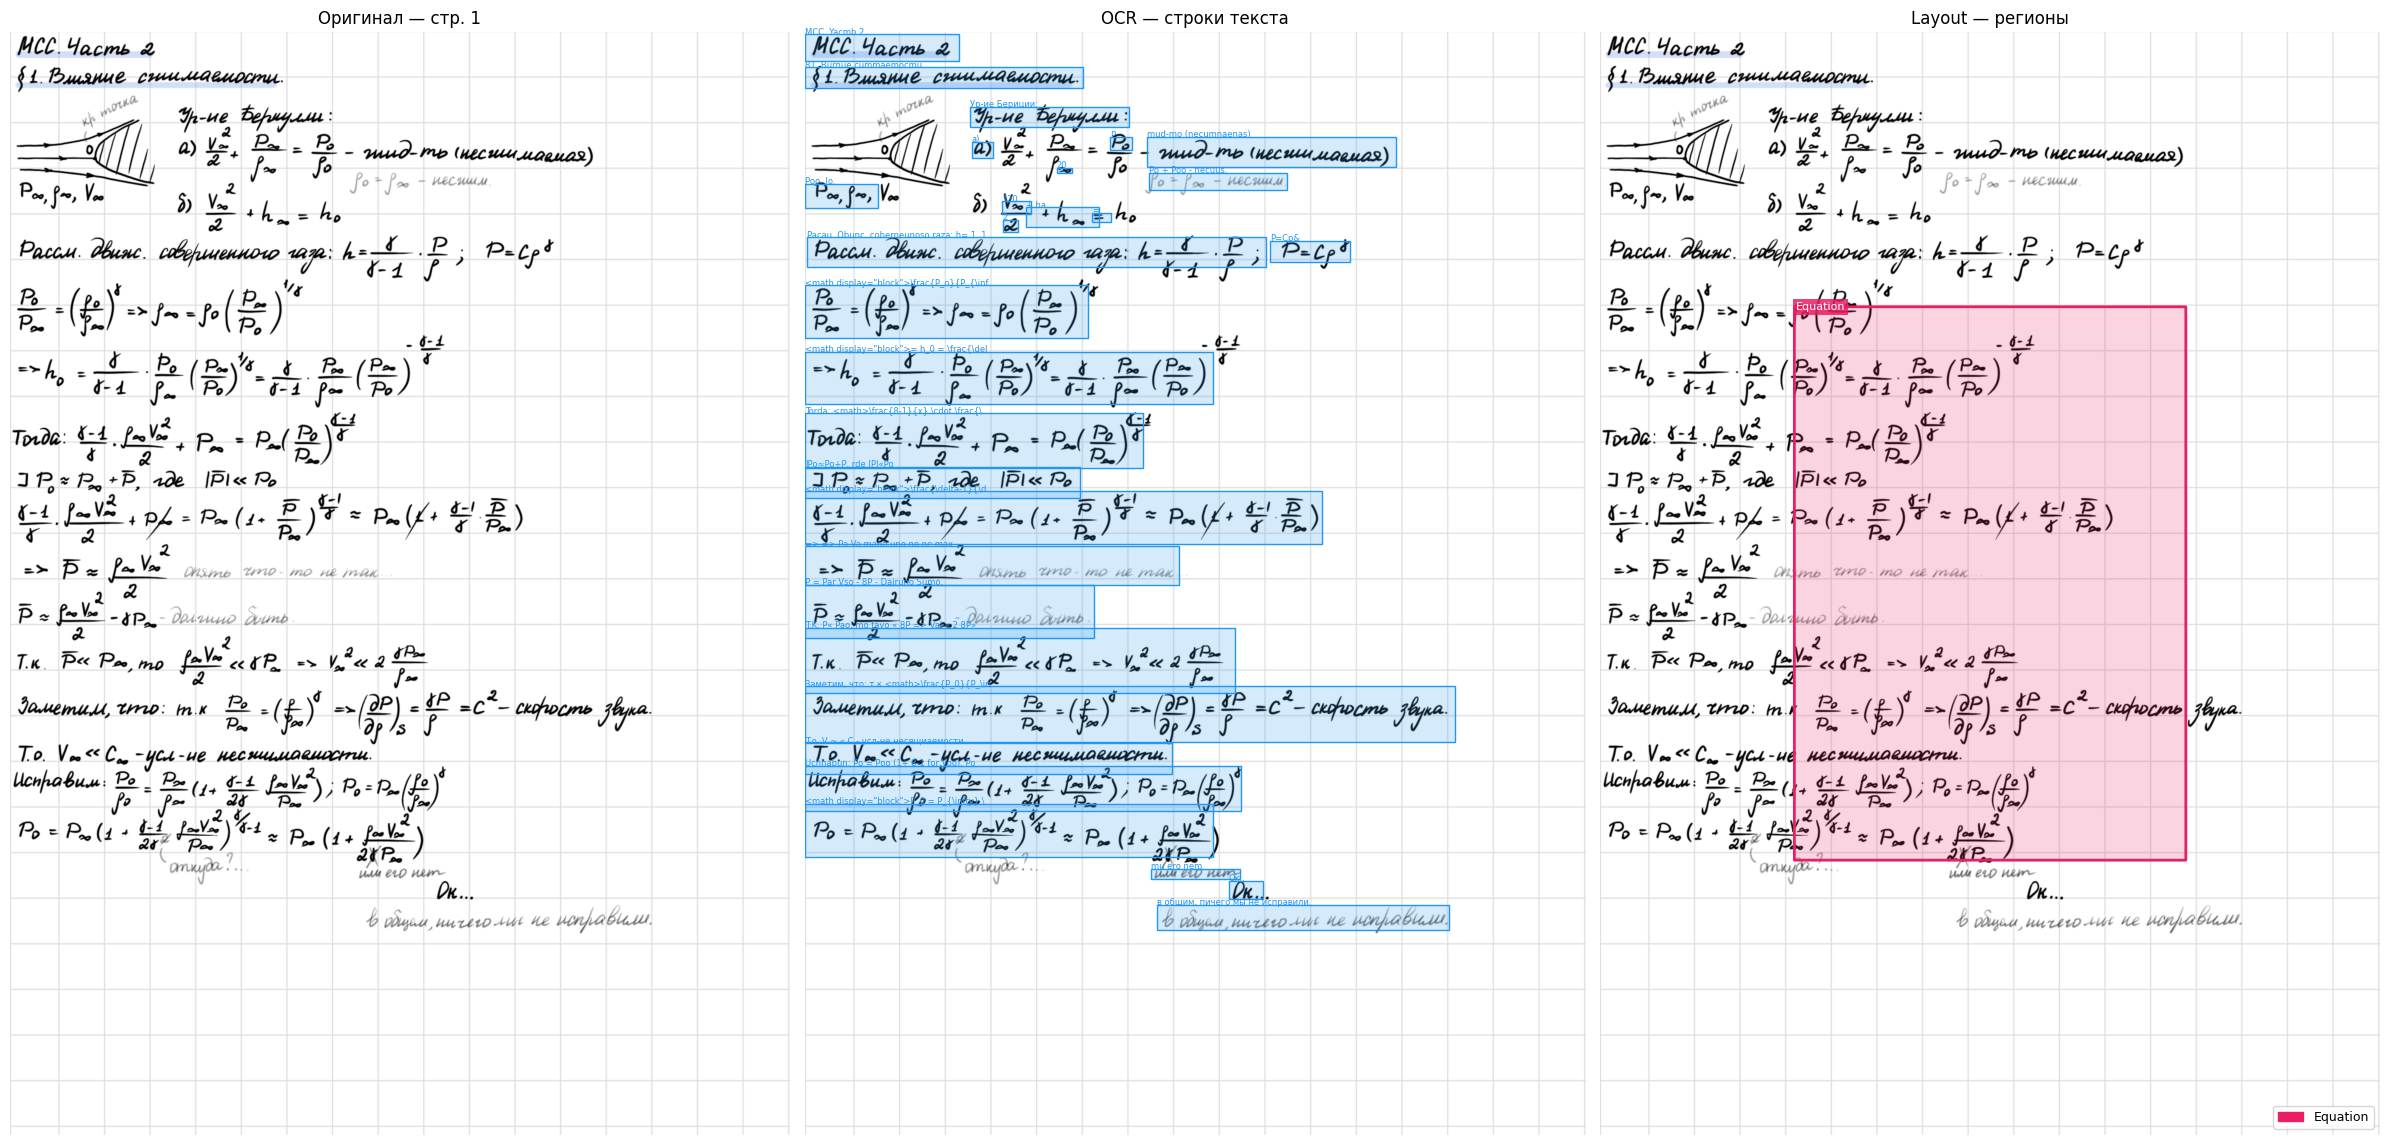

Страница 1:
  Строк распознано : 30
  Регионов layout  : 1
    Equation: 1

  Распознанный текст (первые 5 строк):
    [0.94] MCC. Yacmb 2
    [0.83] 81. Burnue cummaemocmu.
    [0.86] Ур-ие Бериции:
    [0.47] P
    [0.89] mud-mo (necumnaenas)



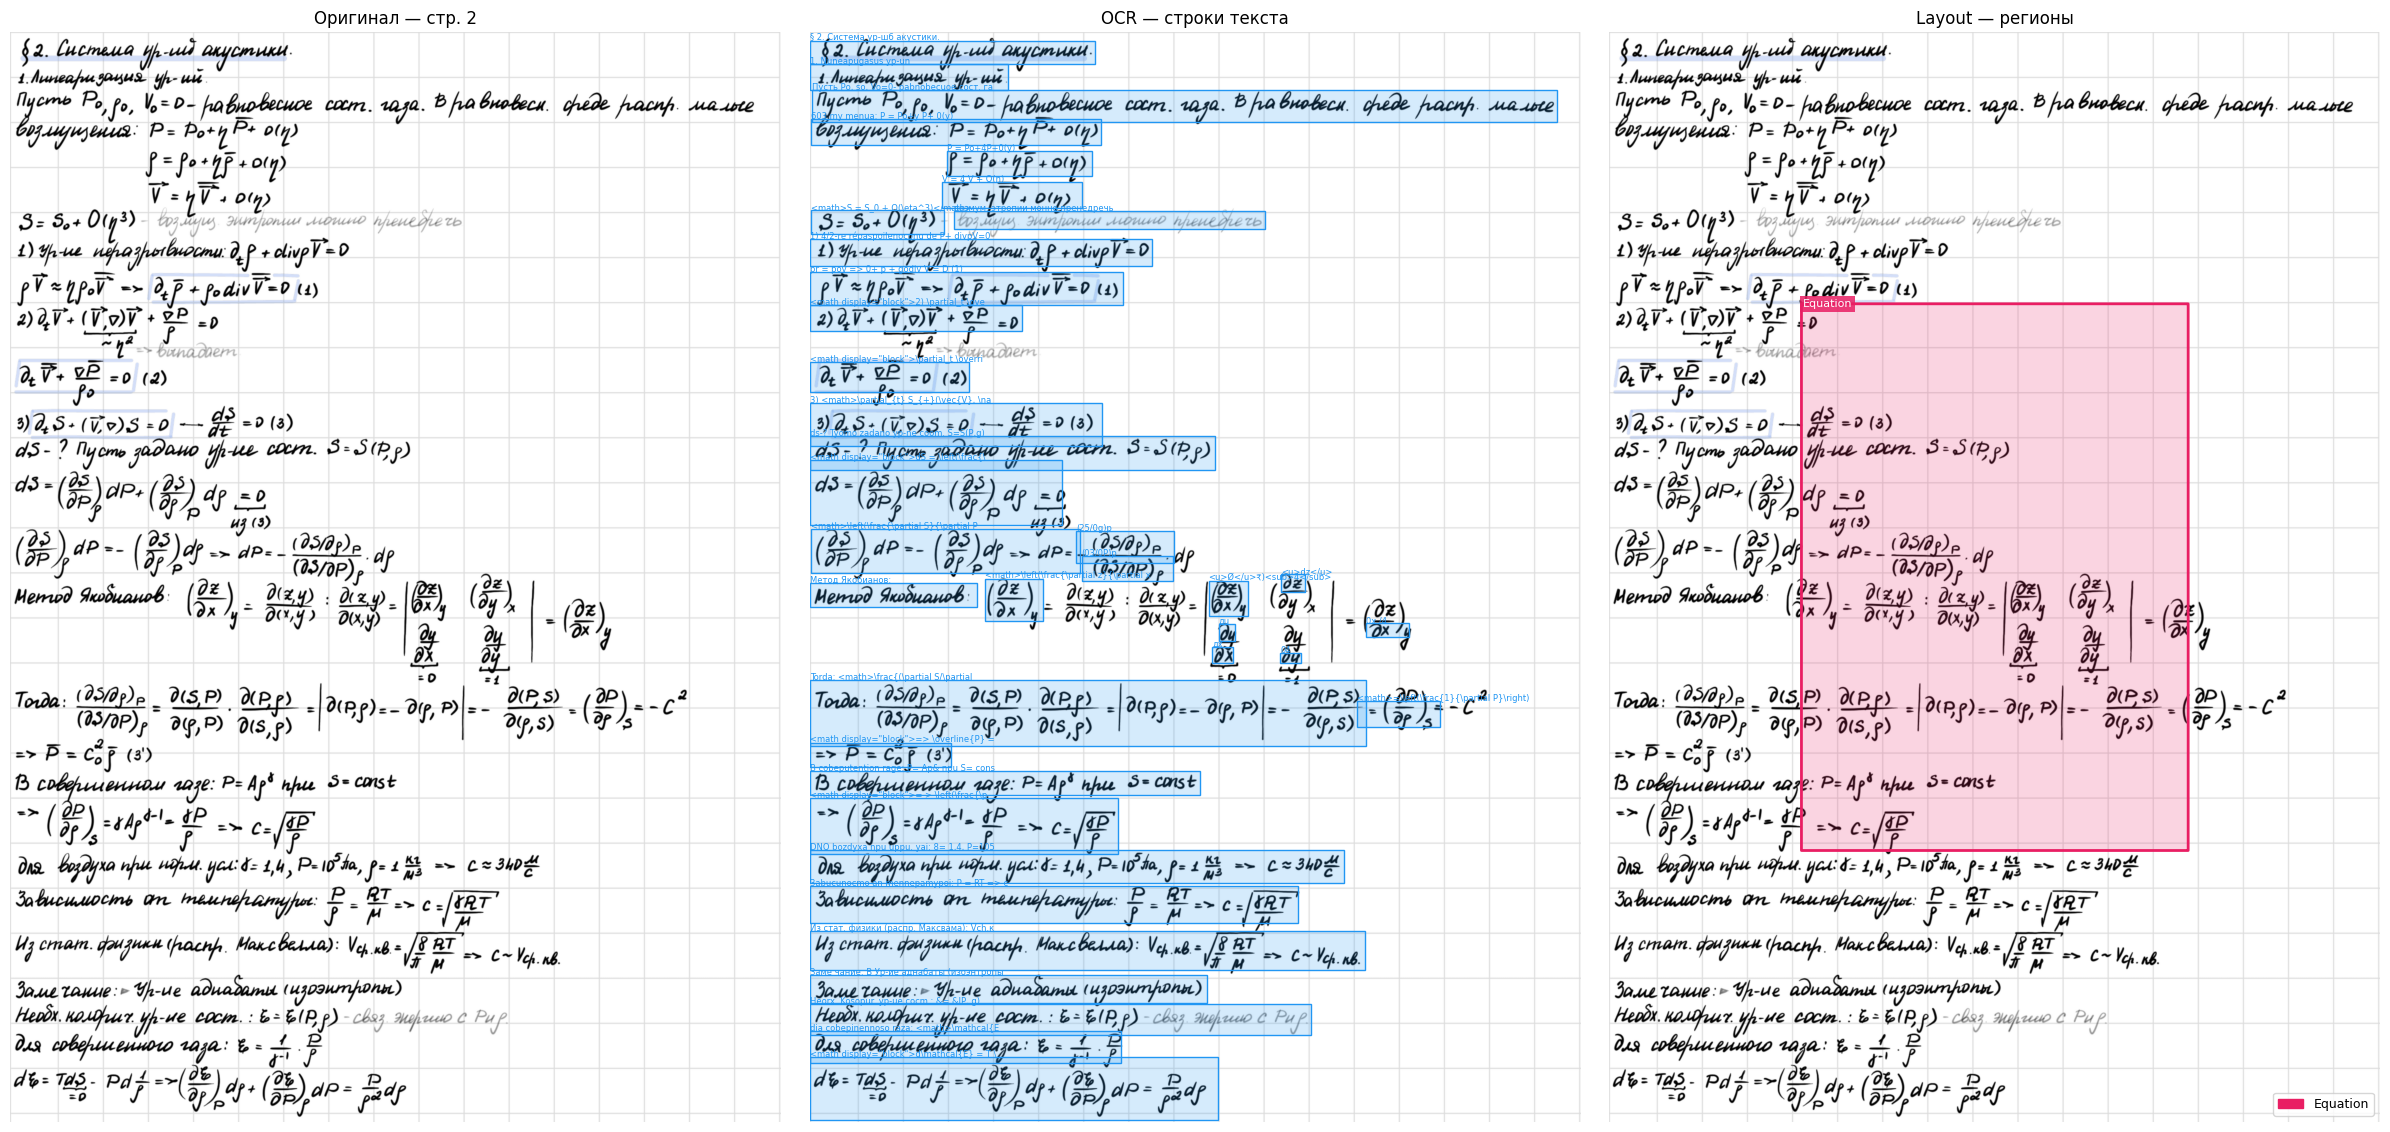

Страница 2:
  Строк распознано : 38
  Регионов layout  : 1
    Equation: 1

  Распознанный текст (первые 5 строк):
    [0.88] § 2. Система ур-шб акустики.
    [0.89] 1. Nuneapugasus yp-un
    [0.89] Пусть Ро, so, Vo=0- pabnobecuoe сост. газа. В равновеси. chede pacup малые
    [0.66] 603 my menua: P = Po+y P+ 0(y)
    [0.66] P = Po+4P+0(y)



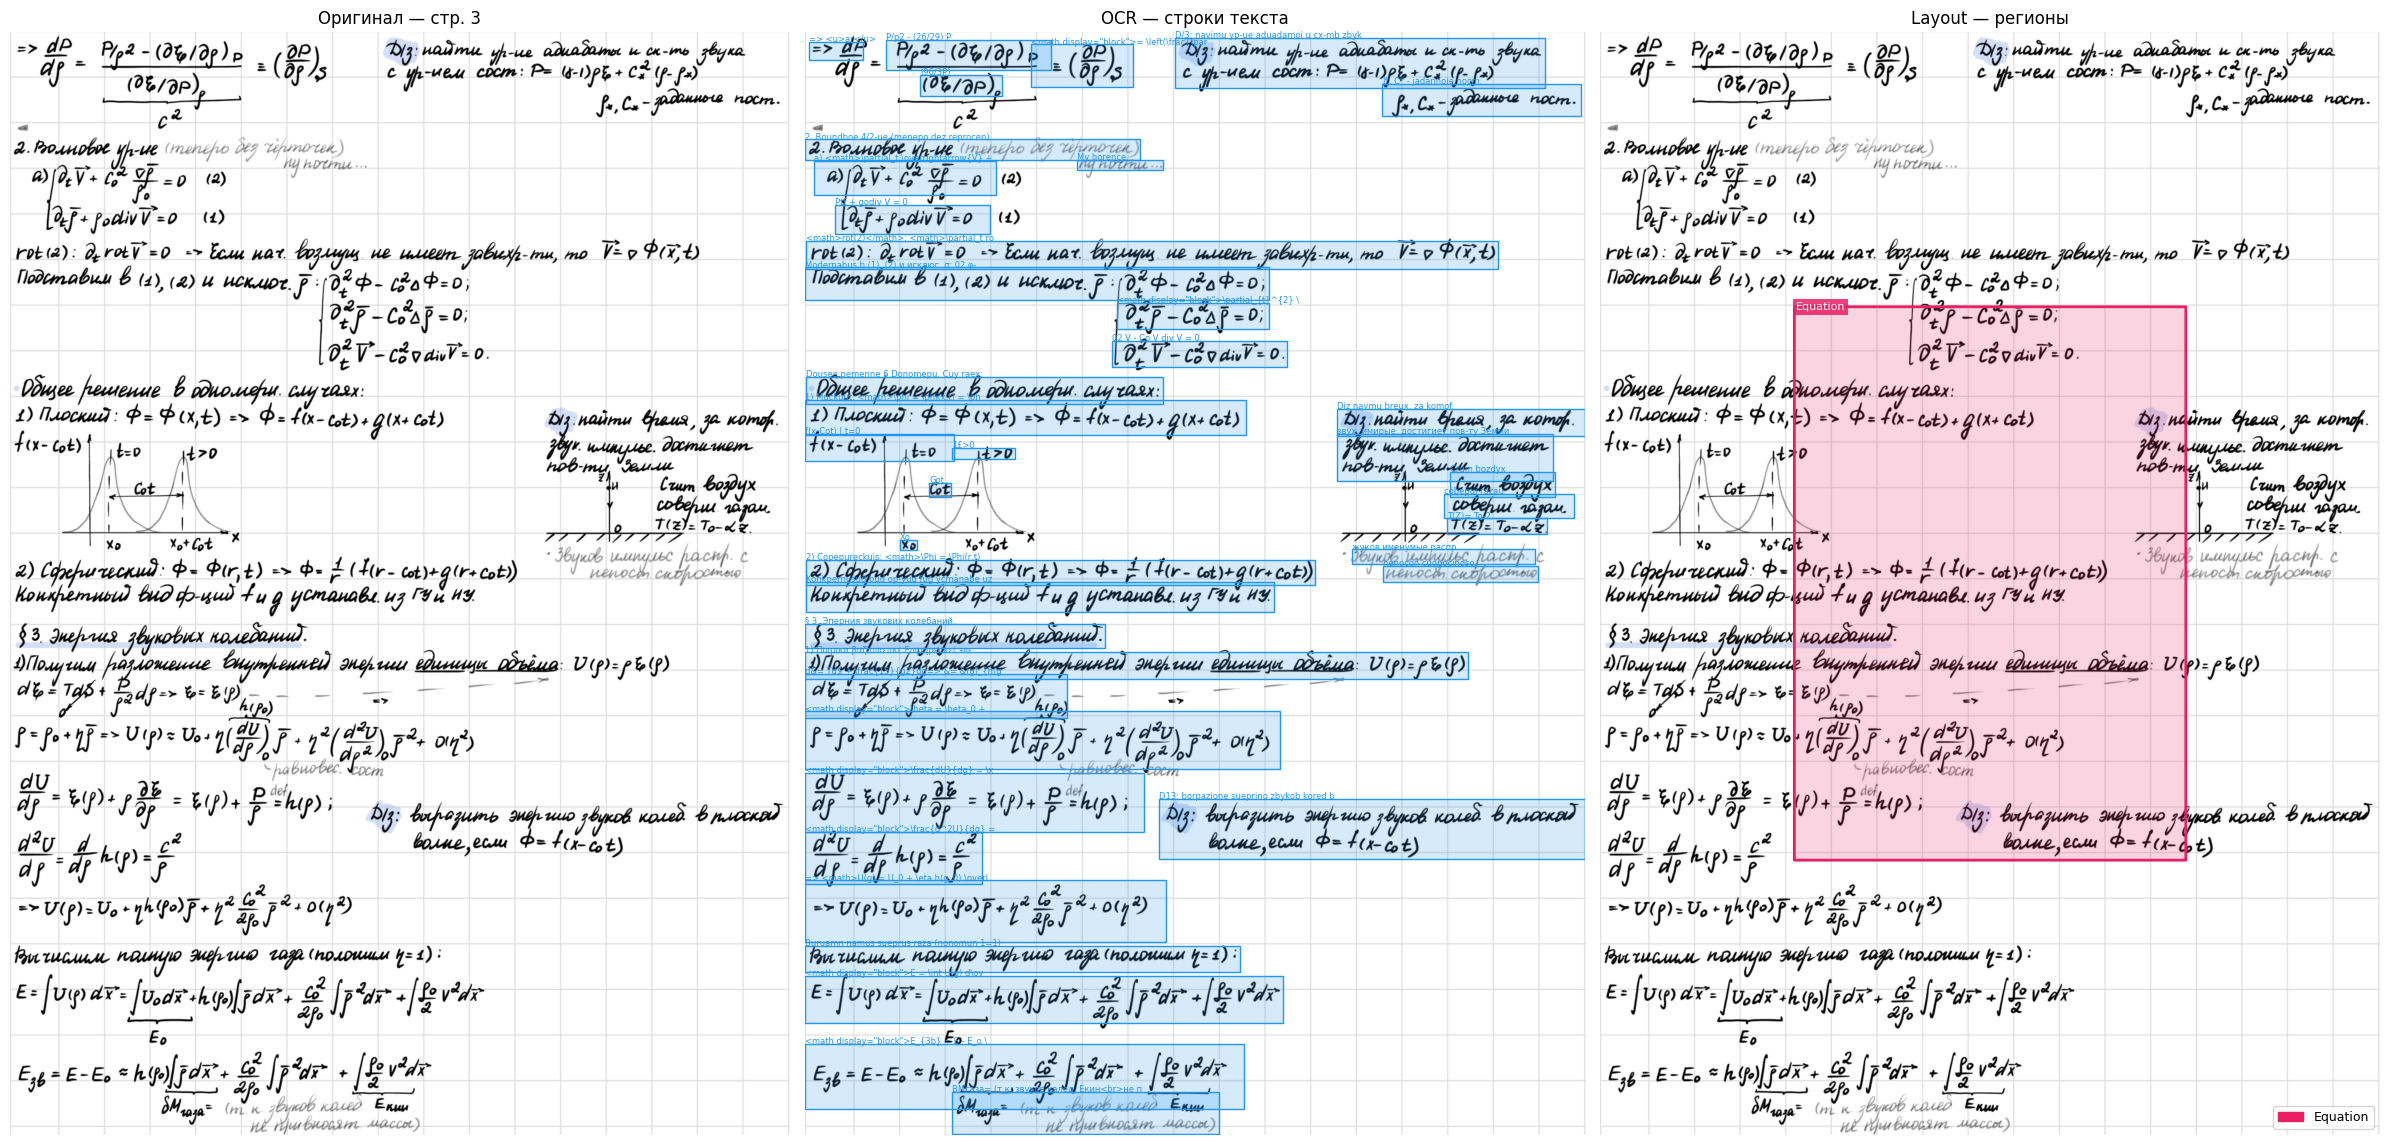

Страница 3:
  Строк распознано : 41
  Регионов layout  : 1
    Equation: 1

  Распознанный текст (первые 5 строк):
    [0.81] D/3: navimu yp-ue aduadamoi u cx-mb zbyka<br>c yp-ueu cocm: P= (8-1) p& + C* (p- p*)
    [0.84] => <u>ar</u>
    [0.91] P/p2 - (26/29) P
    [0.93] <math display="block">= \left(\frac{\partial P}{\partial r}\right)_{5}</math>
    [0.77] (96/3P)



In [10]:


# -- Выбор страниц ---------------------------------------------
indices = [p - 1 for p in PAGES_TO_CHECK if 1 <= p <= len(all_images)]
images  = [all_images[i] for i in indices]

# -- OCR -------------------------------------------------------
print("OCR...")
ocr_preds = recognition_predictor(images, det_predictor=detection_predictor)

# -- Layout ----------------------------------------------------
print("Layout...")
layout_preds = layout_predictor(images)
print("Готово.\n")

# -- Визуализация ----------------------------------------------
CLASS_COLORS = {
    "Text": "#2196F3", "Handwriting": "#2196F3",
    "Formula": "#FF5722", "Text-inline-math": "#FF5722",
    "Figure": "#4CAF50", "Picture": "#4CAF50",
    "Table": "#9C27B0", "Section-header": "#00BCD4",
    "Page-header": "#607D8B", "Page-footer": "#9E9E9E",
}
DEFAULT_COLOR = "#E91E63"

for i, (img, ocr, layout) in enumerate(zip(images, ocr_preds, layout_preds)):
    page_no = indices[i] + 1
    fig, axes = plt.subplots(1, 3, figsize=(24, 12))

    # Оригинал
    axes[0].imshow(img); axes[0].set_title(f"Оригинал — стр. {page_no}"); axes[0].axis("off")

    # OCR — детекция строк
    axes[1].imshow(img); axes[1].set_title("OCR — строки текста"); axes[1].axis("off")
    for line in ocr.text_lines:
        x0,y0,x1,y1 = line.bbox
        axes[1].add_patch(mpatches.Rectangle(
            (x0,y0), x1-x0, y1-y0, linewidth=1, edgecolor="#2196F3", facecolor="#2196F330"
        ))
        axes[1].text(x0, y0-2, line.text[:40], fontsize=6, color="#2196F3")

    # Layout — классификация регионов
    axes[2].imshow(img); axes[2].set_title("Layout — регионы"); axes[2].axis("off")
    seen = {}
    for bbox in layout.bboxes:
        color = CLASS_COLORS.get(bbox.label, DEFAULT_COLOR)
        x0,y0,x1,y1 = bbox.bbox
        axes[2].add_patch(mpatches.FancyBboxPatch(
            (x0,y0), x1-x0, y1-y0, boxstyle="round,pad=2",
            linewidth=2, edgecolor=color, facecolor=color+"30"
        ))
        axes[2].text(x0+4, y0+16, bbox.label, fontsize=8, color="white",
                     bbox=dict(facecolor=color, alpha=0.85, pad=2, edgecolor="none"))
        seen[bbox.label] = color

    axes[2].legend(handles=[mpatches.Patch(color=c, label=l) for l,c in seen.items()],
                   loc="lower right", fontsize=9)
    plt.tight_layout(); plt.show()

    # Статистика
    print(f"Страница {page_no}:")
    print(f"  Строк распознано : {len(ocr.text_lines)}")
    print(f"  Регионов layout  : {len(layout.bboxes)}")
    counts = Counter(b.label for b in layout.bboxes)
    for lbl, cnt in counts.most_common():
        print(f"    {lbl}: {cnt}")

    print("\n  Распознанный текст (первые 5 строк):")
    for line in ocr.text_lines[:5]:
        print(f"    [{line.confidence:.2f}] {line.text}")
    print()